In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Healthcare: measurements are not a diagnosis

**Beginner route:** read the [case lesson](../lessons/wdbc.md) and [dataset card](../cards/wdbc.md). Predict each result before executing.

Source: [Wolberg, Mangasarian, Street and Street (1993), Breast Cancer Wisconsin (Diagnostic), UCI.](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). Snapshot obtained by offline export from sklearn 1.8.0. Numerical results below are our computations, not source claims.

This fixed test partition is a teaching demonstration, not an untouched future benchmark.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, confusion_matrix
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/shape_lab").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.industries import *
from shape_lab.persistence import rips_filtration, persistent_homology, diagram
CASE = "wdbc"
OUT = ROOT / "reports/v6/industries" / CASE
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260920

def write_json(name, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        raise TypeError(type(x).__name__)
    (OUT / name).write_text(json.dumps(value, indent=2, default=convert, allow_nan=False))

def plot_done(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + ".png"), dpi=125)
    plt.show()

def regression_metrics(y, pred):
    return {"mae":float(mean_absolute_error(y,pred)),"rmse":float(mean_squared_error(y,pred)**.5)}

def class_metrics(y, pred):
    return {"accuracy":float(accuracy_score(y,pred)),"balanced_accuracy":float(balanced_accuracy_score(y,pred))}

def stratified_split(y):
    index=np.arange(len(y))
    train, other=train_test_split(index,test_size=.4,random_state=SEED,stratify=y)
    val,test=train_test_split(other,test_size=.5,random_state=SEED,stratify=y[other])
    return {"train":np.sort(train),"validation":np.sort(val),"test":np.sort(test)}

def save_split(split, ids):
    frames=[pd.DataFrame({"example_index":v,"source_id":np.asarray(ids)[v],"partition":k}) for k,v in split.items()]
    pd.concat(frames,ignore_index=True).to_csv(OUT / "split.csv",index=False)

def topology_report(points, name):
    bars=persistent_homology(rips_filtration(points,max_homology=1),max_dim=1)
    finite=[{"dimension":b.dim,"birth":b.birth,"death":b.death} for b in bars if np.isfinite(b.death)]
    write_json(name+".json",{"points":len(points),"coefficient_field":2,"edge_convention":"distance <= epsilon","finite_bars":finite,"essential_h0":1,"role":"exploratory descriptor, not significance"})
    plt.figure(figsize=(7,4))
    for dim in (0,1):
        a=diagram(bars,dim,finite_only=True)
        if len(a): plt.scatter(a[:,0],a[:,1],label="H"+str(dim),s=22)
    plt.xlabel("Birth (declared metric units)");plt.ylabel("Death (same units)");plt.title(name.replace('_',' '));plt.legend()
    plot_done(name)
    return finite

df, meta = load_dataset(CASE)
print(meta["title"])
print("Shape:",df.shape,"; snapshot SHA-256:",meta["data_sha256"])
print("Observation unit:",meta["observation_unit"])
display(df.head())
write_json("protocol.json",{"dataset":CASE,"seed":SEED,"data_sha256":meta["data_sha256"],"code_sha256":hashlib.sha256((ROOT/"src/shape_lab/industries.py").read_bytes()).hexdigest(),"data_kind":"observed","evaluation":"fixed teaching experiment; displayed test outcomes are now exposed","external_validation":False})


Cell-image measurements and honest classification
Shape: (569, 32) ; snapshot SHA-256: 67a1bb2aa650da2ba7c76b5f64e1a180e00f50dcb0e91a2650be35d6251116dd
Observation unit: One digitized fine-needle-aspirate image summary. The scikit-learn snapshot does not retain original IDs.


,row_id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1. Define the independent example before fitting

Each row summarizes nuclei in a digitized fine-needle-aspirate image. These are not raw images. The sklearn snapshot lacks the original identifiers, so we cannot verify a patient-disjoint or hospital-disjoint test. We map **malignant to 1** explicitly. No threshold or model in this lesson is a clinical recommendation.

Predict: which columns would leak the answer or identify a row rather than measure the specimen?

In [3]:
features=[c for c in df if c not in ("row_id","label")]
x=df[features].to_numpy(float)
y=(df.label.to_numpy()==0).astype(int)  # positive class = malignant
split=stratified_split(y);save_split(split,df.row_id)
scaler=TrainScaler.fit(x[split["train"]]);z=scaler.transform(x)
write_json("preprocessing.json",{"feature_names":features,"mean":scaler.mean,"scale":scaler.scale,"fit_rows":split["train"],"positive_class":"malignant"})
print({k:{"n":len(v),"malignant":int(y[v].sum())} for k,v in split.items()})
assert not(set(split["train"]) & set(split["test"]))

{'train': {'n': 341, 'malignant': 127}, 'validation': {'n': 114, 'malignant': 42}, 'test': {'n': 114, 'malignant': 43}}


## 2. Establish a fixed, explainable baseline

A logistic model maps a linear score to a number between zero and one. That number is not automatically calibrated for a new hospital. We fix C=1 before viewing validation or test results. Accuracy can hide unequal class performance, so we also report balanced accuracy, a confusion matrix, and ROC AUC. All preprocessing parameters come from training rows.

In [4]:
model=LogisticRegression(C=1,max_iter=3000,random_state=SEED).fit(z[split["train"]],y[split["train"]])
majority=int(np.bincount(y[split["train"]]).argmax());scores={}
for key in ("validation","test"):
    ix=split[key];p=model.predict_proba(z[ix])[:,1];pred=(p>=.5).astype(int)
    scores[key]={"logistic":class_metrics(y[ix],pred),"majority":class_metrics(y[ix],np.full(len(ix),majority)),"roc_auc":float(roc_auc_score(y[ix],p)),"confusion_true_rows_pred_columns":confusion_matrix(y[ix],pred).tolist(),"n":len(ix)}
    pd.DataFrame({"row_id":df.row_id.to_numpy()[ix],"malignant":y[ix],"probability_malignant":p,"prediction":pred}).to_csv(OUT/(key+"_predictions.csv"),index=False)
write_json("results.json",scores);display(pd.DataFrame({k:v["logistic"] for k,v in scores.items()}))

,validation,test
accuracy,0.982456,1.0
balanced_accuracy,0.976190,1.0


## 3. Ask a topological question at the correct level

Now study the geometry of a fixed small training cohort. A persistence diagram belongs to this point cloud and its metric; it is not a separate diagnostic test for each row. A loop can reflect sampling, correlated features or preprocessing. Selecting the most dramatic diagram after inspecting labels would be exploratory selection, not an independent discovery.

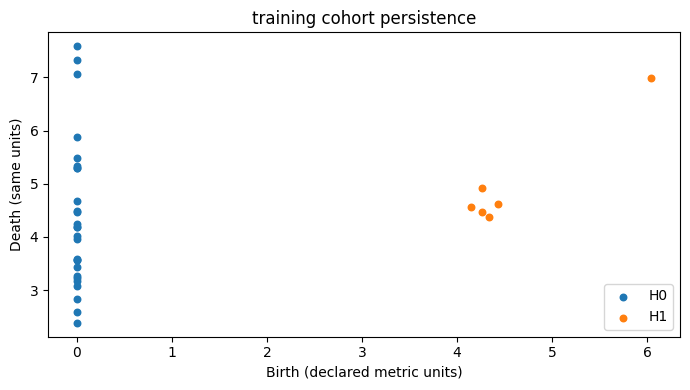

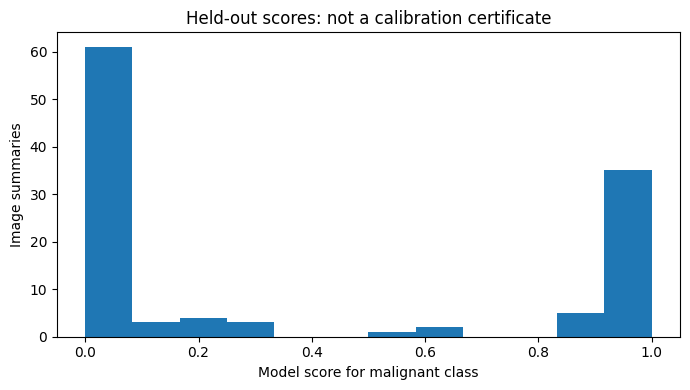

In [5]:
sample=np.random.default_rng(SEED).choice(split["train"],size=28,replace=False)
write_json("topology_rows.json",sample)
_ = topology_report(z[sample],"training_cohort_persistence")
plt.figure(figsize=(7,4));plt.hist(model.predict_proba(z[split["test"]])[:,1],bins=12)
plt.xlabel("Model score for malignant class");plt.ylabel("Image summaries");plt.title("Held-out scores: not a calibration certificate")
plot_done("score_distribution")

## 4. Stop before an unsupported conclusion

**Answer independently:** (a) Why does a row-disjoint test not establish patient independence here? (b) Why does zero training error not prove a clinically usable system? (c) What additional identifiers and validation cohorts would be required?

Do not improve the reported test score by repeatedly trying features. Any further search needs a newly protected evaluation. The source card records the original source and reuse conditions.

## Save your evidence

Create `my_work/industries/wdbc.md` with your prediction, actual result, explanation, one failed assumption and one claim the evidence does not justify. Use the separate learner notebook only after you understand the worked code. No notebook execution automatically marks your learning complete.